In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Question 1

### A

In [88]:
#A.
df = pd.read_csv ('ForeignGifts_edu.csv')

### B

In [89]:
print(df["Gift Type"].dtype)
print(df["Gift Type"].isna().sum())
print(df["Gift Type"].unique())
print(df["Gift Type"].value_counts())

object
0
['Monetary Gift' 'Contract' 'Real Estate']
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64


<Axes: xlabel='Gift Type', ylabel='proportion'>

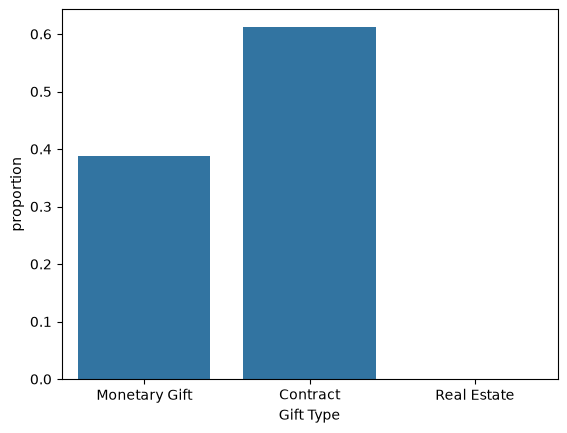

In [90]:
sns.countplot(x=df['Gift Type'],stat='proportion')

The three types of foriegn gifts in this datset are monetary gifts, contracts, and real estate. 
- Monetary gifts: Direct monetary donation
- Contracts: Exchanging a service or other benefit for a contract fee, like consulting service
- Real: Land donation

There are very few real estate gifts to U.S. academic institutions, and contracts make up a majority of the foreign gifts to U.S institutions.

### C

In [91]:

#1.
df.groupby("Country of Giftor").sum("Foreign Gift Amount").sort_values(by="Foreign Gift Amount", ascending=False).head(1)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Country of Giftor,,,,
QATAR,14133760,207860000,29707239,2706240869


The country that gives the most money in total is Qatar at $2,706,240,869.

In [92]:
#2.
df["Country of Giftor"].value_counts().head(1)

Country of Giftor
ENGLAND    3655
Name: count, dtype: int64

The country that initiates the most gifts by count is England.

In [93]:
#3.
df.groupby("Country of Giftor").mean("Foreign Gift Amount").sort_values(by="Foreign Gift Amount", ascending=False).head(1)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Country of Giftor,,,,
BERMUDA,18171.854701,265962.393162,42919.008547,7.688837e+06


The country that gives the largest gifts on average is Bermuda.

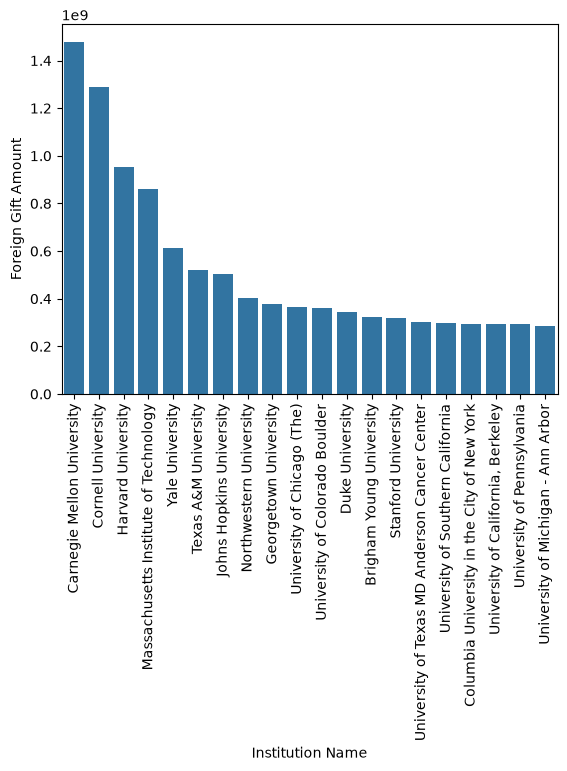

In [94]:
#4.
df_institution_giftamount = df.groupby("Institution Name").sum("Foreign Gift Amount").sort_values(by="Foreign Gift Amount", ascending=False).head(20)

sns.barplot(data = df_institution_giftamount, x="Institution Name", y = "Foreign Gift Amount")
plt.xticks(rotation=90)
plt.show()

Based on the bar chart above, Carnegie Melon University recieved the most money in total.

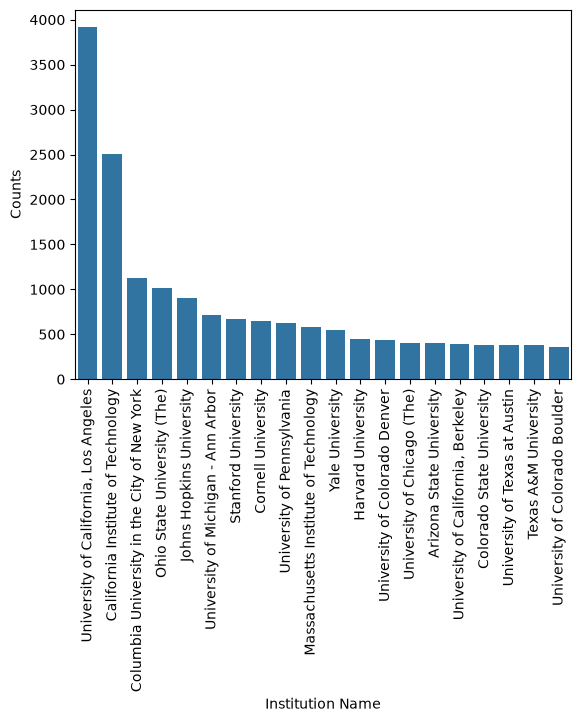

In [95]:
#5
df_institution_count = df["Institution Name"].value_counts().reset_index(name='Counts').head(20)

sns.barplot(data = df_institution_count, x="Institution Name", y = "Counts")
plt.xticks(rotation=90)
plt.show()

The bar chart above shows that University of California, Los Angeles recieved the greatest number of gifts by count.

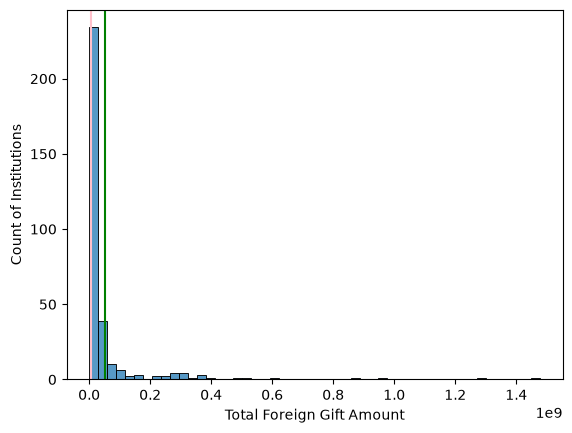

In [96]:
#6.
df_institution_giftamount2 = df.groupby("Institution Name").sum("Foreign Gift Amount")
mean_amount = df_institution_giftamount2['Foreign Gift Amount'].mean()
median_amount = df_institution_giftamount2['Foreign Gift Amount'].median()

sns.histplot(data = df_institution_giftamount2, x = "Foreign Gift Amount", bins=50)
plt.xlabel('Total Foreign Gift Amount')
plt.ylabel('Count of Institutions')

plt.axvline(mean_amount, color='green')
plt.axvline(median_amount, color='pink')

plt.show()

In [97]:
print(mean_amount)
print(median_amount)

52202878.974842764
6486791.5


The histogram above shows that the distribution of total foreign gift amount by institutions is left-skewed with a majority of insitutions having a total foreign gift amount less than 100 million. This is further emphasized with the mean total foreign gift amounts across institutions being $6,486,792 and the median being $52,202,879.

In [98]:
#7.
pd.crosstab(df["Institution Name"], df["Country of Giftor"], values=df["Foreign Gift Amount"], aggfunc="sum").stack().sort_values(ascending = False).head(1)

Institution Name    Country of Giftor
Cornell University  QATAR                1.018473e+09
dtype: float64

This output above shows that the larget flow between a single country and a single institution is from QATAR to Cornell.

In [99]:
#h.
df.groupby('Giftor Name').sum('Foreign Gift Amount').sort_values(by='Foreign Gift Amount', ascending=False).head()

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Giftor Name,,,,
Qatar Foundation,6230548,89110300,11199907,1166503744
Qatar Foundation/Qatar National Res,196298,2711000,425002,796197000
Qatar Foundation for Education,138404,1942000,257508,373945215
Anonymous,5698993,79905200,11294891,338793629
Saudi Arabian Cultural Mission,7422014,136674400,20713305,275221475


The table above shows that the top giftor was Qatar Foundation, with Qatar Foundation/Qatar National Res and Qatar Foundation for Education coming in second and third respectively. The chart below emphazies that these giftors had some of the largest flows into indvidual institutions as well, such as with Qatar Foundation/Qatar National Res to Cornell.

In [100]:
import plotly.graph_objects as go

giftor = 'Giftor Name'
#giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()